In [34]:
import pandas as pd
import seaborn as sns

In [35]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [36]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [37]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#Univariate Analysis

In [38]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


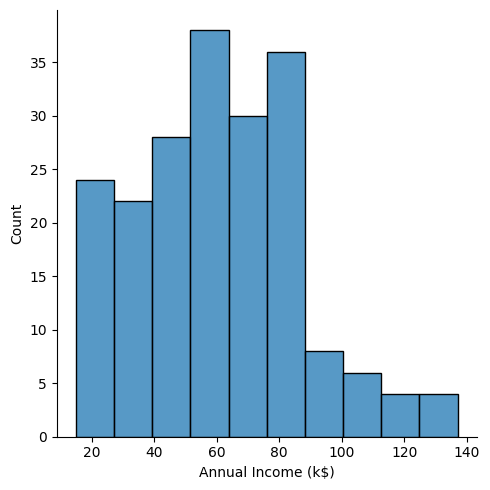

In [39]:
sns.displot(df['Annual Income (k$)'])

<Figure size 640x480 with 0 Axes>

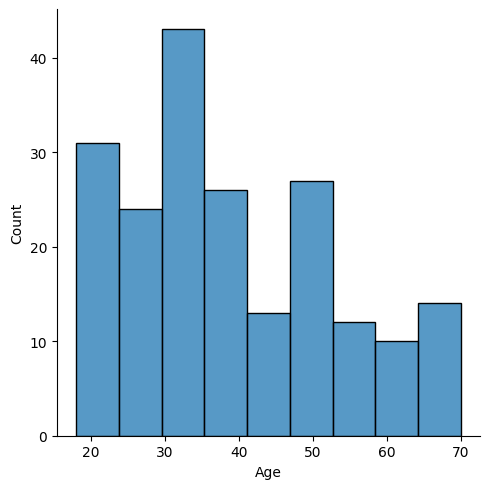

<Figure size 640x480 with 0 Axes>

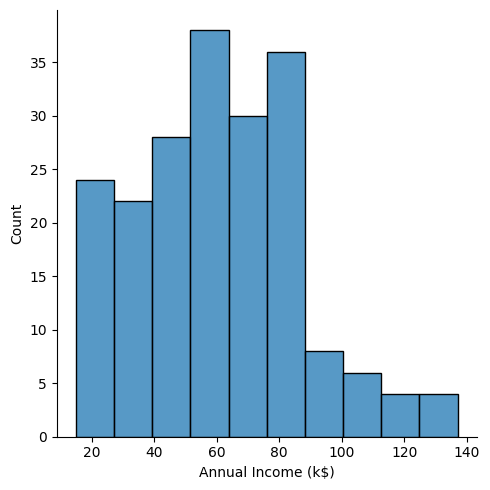

<Figure size 640x480 with 0 Axes>

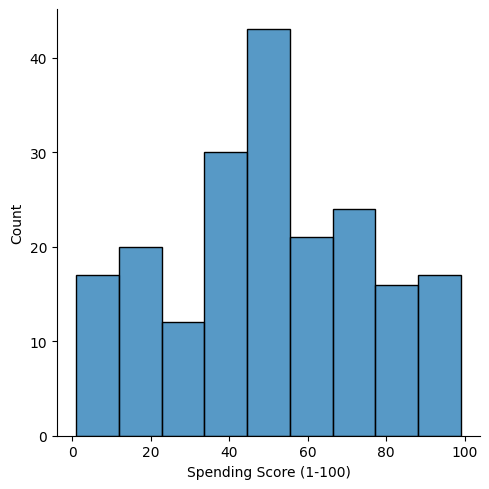

In [40]:
columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i in columns:
  plt.figure()
  sns.displot(df[i])

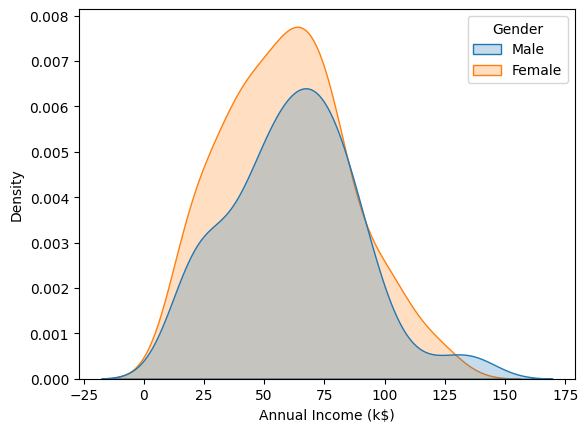

In [41]:
sns.kdeplot(data=df, x='Annual Income (k$)', fill=True, hue='Gender');

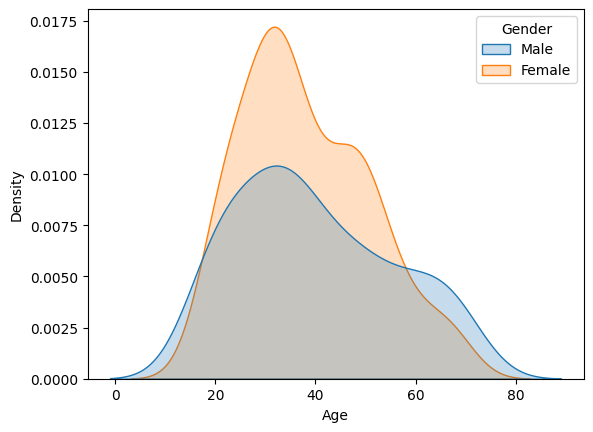

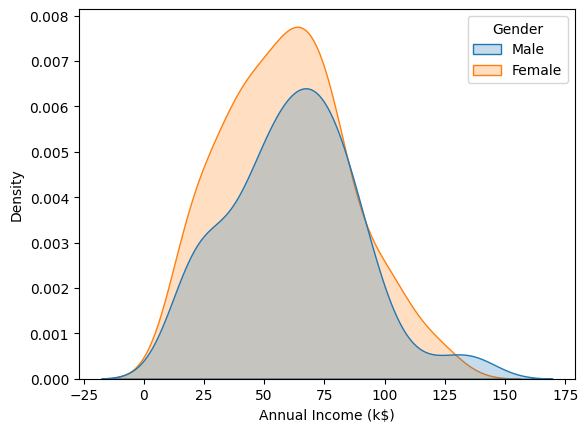

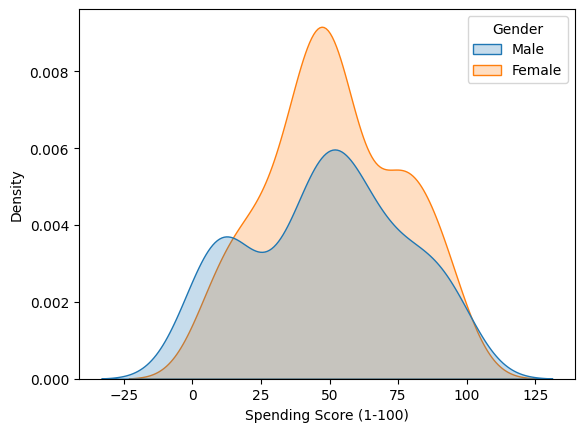

In [42]:
columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i in columns:
  plt.figure()
  sns.kdeplot(data=df, x=i, fill=True, hue='Gender');

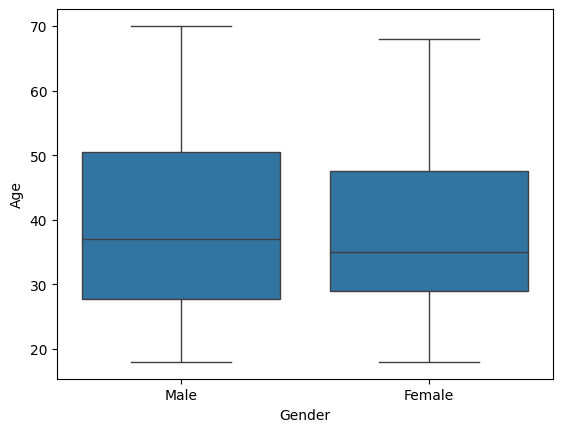

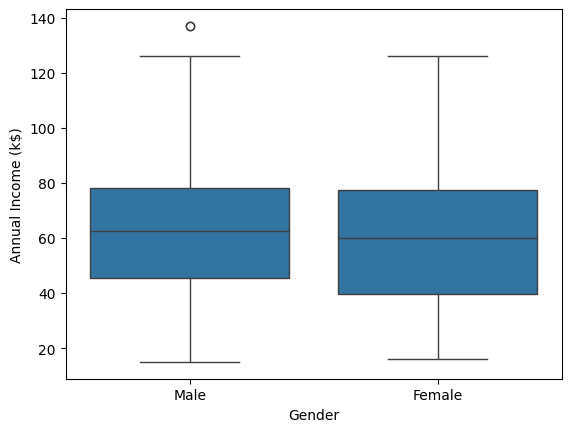

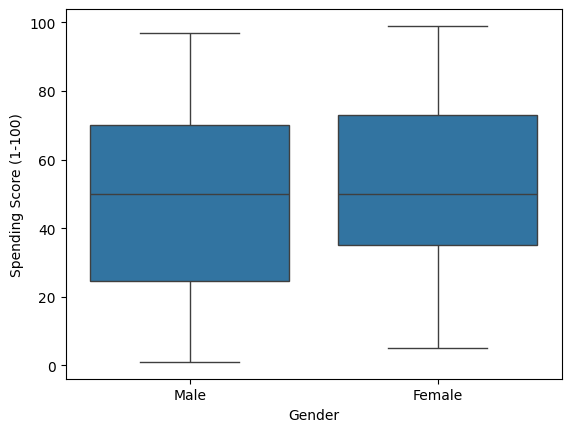

In [43]:
columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i in columns:
  plt.figure()
  sns.boxplot(data=df, x='Gender', y=i);

In [44]:
df['Gender'].value_counts(normalize=True)

,proportion
Gender,
Female,0.56
Male,0.44


#Bivariate Analysis

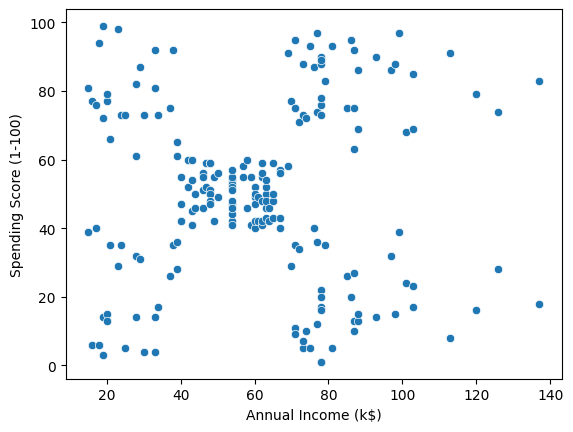

In [45]:
sns.scatterplot(data=df, x='Annual Income (k$)',y='Spending Score (1-100)');

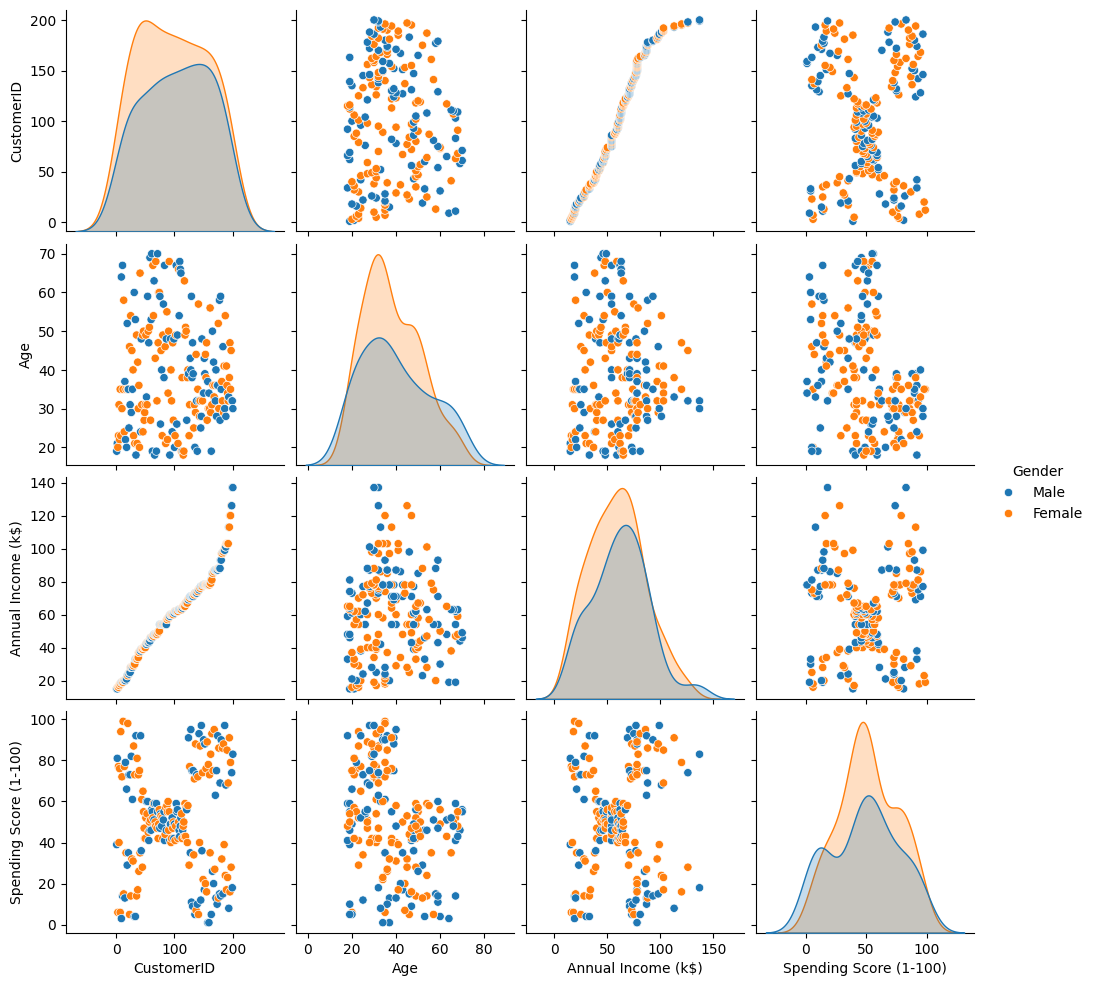

In [46]:
# df=df.drop('CustomerID', axis=1)
sns.pairplot(df, hue='Gender')

In [47]:
df.groupby(['Gender'])[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [48]:
df.drop('Gender', axis=1).corr()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


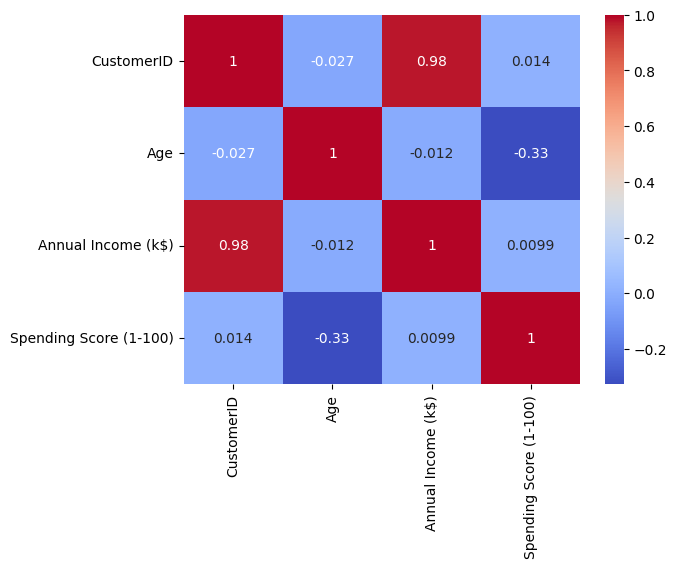

In [49]:
sns.heatmap(df.drop('Gender', axis=1).corr(), annot=True, cmap='coolwarm');

#Clustering - UNivariate, Bivariate, MultiVariate

In [50]:
clustering1 = KMeans()
clustering1.fit(df[['Annual Income (k$)']])

KMeans()

In [51]:
clustering1.labels_

array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 5, 5, 5,
       5, 5], dtype=int32)

In [52]:
df['Income Cluster'] = clustering1.labels_

In [53]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,4
3,4,Female,23,16,77,4
4,5,Female,31,17,40,4


In [54]:
df['Income Cluster'].value_counts()

,count
Income Cluster,
0,52
3,38
6,26
1,24
4,22
7,16
2,16
5,6


In [55]:
clustering1.inertia_

3579.563703840018

In [56]:
inertia_scores = []
for i in range(1,11):
  clustering1 = KMeans(n_clusters=i)
  clustering1.fit(df[['Annual Income (k$)']])
  inertia_scores.append(clustering1.inertia_)

In [57]:
inertia_scores

[137277.2800000002,
 49761.737012987025,
 23528.152173913048,
 14631.886877828056,
 8493.229304029299,
 5081.484660267269,
 4247.342307692307,
 3287.3953823953834,
 2393.1442057942068,
 1786.2085081585085]

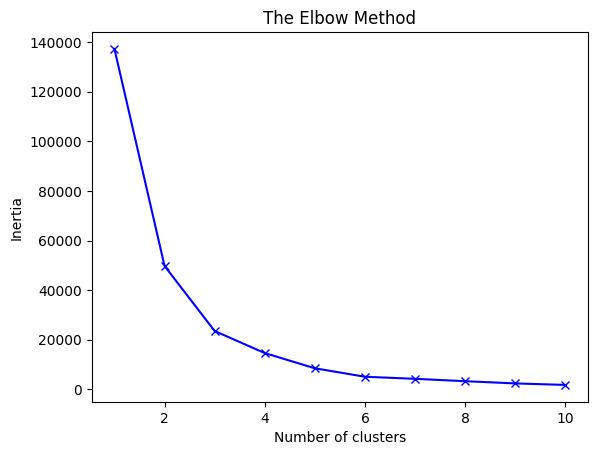

In [58]:
plt.plot(range(1,11), inertia_scores, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('The Elbow Method')
plt.show()

In [59]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Income Cluster'],
      dtype='object')

In [60]:
df.groupby('Income Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Income Cluster,,,
0,36.365385,78.692308,49.423077
1,41.333333,41.416667,50.833333
2,37.812500,100.875000,52.875000
3,40.368421,63.157895,50.157895
4,33.318182,19.272727,51.227273
5,36.833333,127.666667,49.666667
6,46.038462,51.615385,51.153846
7,37.312500,30.000000,46.437500


**Bivariate CLustering**

In [65]:
clustering2 = KMeans(n_clusters=5)
clustering2.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
df['Spending Cluster'] = clustering2.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending Cluster
0,1,Male,19,15,39,4,0
1,2,Male,21,15,81,4,3
2,3,Female,20,16,6,4,0
3,4,Female,23,16,77,4,3
4,5,Female,31,17,40,4,0


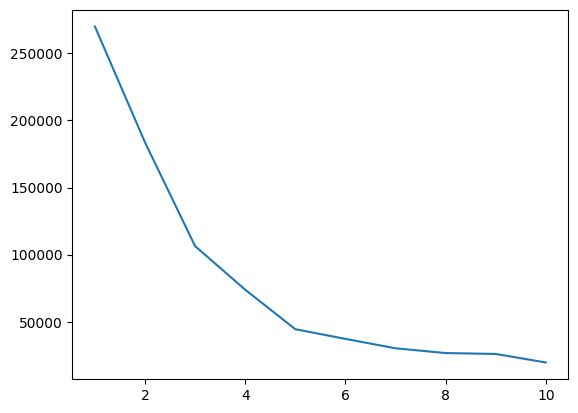

In [64]:
inertia_scores2 = []
for i in range(1,11):
  kmeans2 = KMeans(n_clusters=i)
  kmeans2.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
  inertia_scores2.append(kmeans2.inertia_)
plt.plot(range(1,11), inertia_scores2)


In [78]:
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ['x', 'y']

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

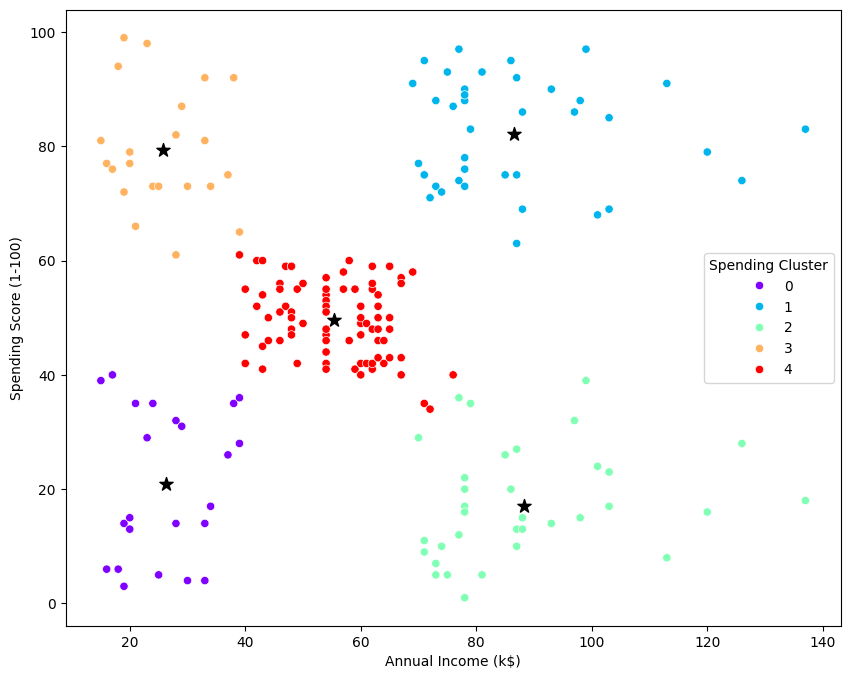

In [82]:
plt.figure(figsize=(10,8))
plt.scatter(x=centers['x'],y=centers['y'], s=100, c='black', marker='*')
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Spending Cluster', palette='rainbow')

In [81]:
pd.crosstab(df['Spending Cluster'], df['Gender'], normalize='index')

Gender,Female,Male
Spending Cluster,,
0,0.608696,0.391304
1,0.538462,0.461538
2,0.457143,0.542857
3,0.590909,0.409091
4,0.592593,0.407407


In [83]:
df.groupby('Spending Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending Cluster,,,
0,45.217391,26.304348,20.913043
1,32.692308,86.538462,82.128205
2,41.114286,88.200000,17.114286
3,25.272727,25.727273,79.363636
4,42.716049,55.296296,49.518519
